**Project: Serious Mental Illness (SMI) among Adults Receiving Public Mental Health Services: A Predictive Analysis.**

**Business Problem**


*   **Statement of the problem**

The state Mental Health Agency (SMHA) operates programs or provides funding for mental health and support services for individuals in each state in the United States and its territories. Yearly, millions of people benefit from this public funding and free access to mental health services. Individual clients receive services including screening, assessment, crisis intervention, and telemedicine services. The primary service delivery agencies across each State reports a maximum of three diagnoses per individual per year; this may be more or fewer diagnoses, or none. However, it is a clear indication that mental illness is quite prevalent in the United States, while funding resources may be limited, requiring efficient allocation. Therefore, service delivery agencies need to be able to quickly identify individuals who are likely to meet the criteria for serious mental illness (SMI), so that care coordination, intervention services, and risk monitoring can be prioritized for them by these agencies.       

*   **Business Question**

This project aims to build machine learning models capable of predicting whether an individual receiving publicly funded mental health care will be classified as having serious mental illness (SMI) using client-level records of clinical diagnoses, publicly funded service use, and client demographics. To achieve this aim, the following questions will be explored.

1. Can we predict SMI from individual demographic, clinical, and service variables?

2. Does geography provide additional predictive information beyond individual characteristics?

3. Are there distinct behavioral health client profiles within the MH-CLD population that can help inform service planning, risk stratification, and future mental health product development?

*   **Project Data**

This project focuses on the adult population served in 2023, using the open-source mental health client-level data (MH_CLD) available on the SAMHSA website (https://www.samhsa.gov/data/data-we-collect/mh-cld-mental-health-client-level-data/datafiles/2023). This data includes reports of the demography, diagnosis, substance use, employment, residential data, and service-use of individuals served through the state mental health agencies for the year. The data includes one record per individual served and a total of 7,035,641 records.

Exclusion: American Samoa, Guam, Maine, Marshall Islands, U.S. Virgin Islands and Federated States of Micronesia reported insufficient data and were excluded from the 2023 report by the Center for Behavioral Health Statistics and Quality, Substance Abuse and Mental Health Services Administration (SAMHSA).



*   **Executive Value**

*   Accurate prediction of SMI can support earlier detection of the presence of SMI in an individual, improve the speed of intervention, psychiatric stabilization, and care coordination, including housing support and other adjacent wellness support.
*   Accurate prediction of SMI can support the identification of indicators of risks SMI in individuals beyond symptoms and diagnosis.












**Analysis - Load libraries**

In [1]:
# Set up

!pip install missingno

In [2]:
# Libraries

# =========================
# Data Manipulation
# =========================
import pandas as pd
import numpy as np

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# =========================
# Data Preprocessing
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# =========================
# Model Evaluation
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# =========================
# Plot Style
# =========================
sns.set_style("whitegrid")

**Data Exploration**


* Load and inspect each dataset
* Check data types, shapes, and basic statistics
* Visualize distributions of numerical features
* Explore categorical variable frequencies
* Identify the target variable and check class balance



**Mount Google Drive**

In [3]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive')


#Load data from google drive
file_path = '/content/drive/MyDrive/BUAL 7000 Project/mhcld_puf_2023.csv'

df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Explore Data Struucture**

In [4]:
# Dataset size

df.shape


(7213557, 40)

In [5]:
# First 5 rows of Data

df.head()


,YEAR,AGE,EDUC,ETHNIC,RACE,SPHSERVICE,CMPSERVICE,OPISERVICE,RTCSERVICE,IJSSERVICE,...,PDDFLG,PERSONFLG,SCHIZOFLG,ALCSUBFLG,OTHERDISFLG,STATEFIP,DIVISION,REGION,CASEID,SEX
0,2023,13,-9,3,6,2,1,1,2,2,...,0,0,0,0,0,1,6,3,20230000001,1
1,2023,4,-9,-9,-9,2,1,2,2,2,...,0,0,0,0,0,1,6,3,20230000002,1
2,2023,10,4,4,6,1,2,2,2,2,...,0,0,1,0,0,1,6,3,20230000003,1
3,2023,6,-9,4,2,2,1,1,2,2,...,0,0,0,0,0,1,6,3,20230000004,1
4,2023,14,-9,4,3,1,1,2,2,2,...,0,0,0,0,0,1,6,3,20230000005,1


In [6]:
# Feature (Variable) Names

df.columns


Index(['YEAR', 'AGE', 'EDUC', 'ETHNIC', 'RACE', 'SPHSERVICE', 'CMPSERVICE',
       'OPISERVICE', 'RTCSERVICE', 'IJSSERVICE', 'MH1', 'MH2', 'MH3', 'SUB',
       'MARSTAT', 'SMISED', 'SAP', 'EMPLOY', 'DETNLF', 'VETERAN', 'LIVARAG',
       'NUMMHS', 'TRAUSTREFLG', 'ANXIETYFLG', 'ADHDFLG', 'CONDUCTFLG',
       'DELIRDEMFLG', 'BIPOLARFLG', 'DEPRESSFLG', 'ODDFLG', 'PDDFLG',
       'PERSONFLG', 'SCHIZOFLG', 'ALCSUBFLG', 'OTHERDISFLG', 'STATEFIP',
       'DIVISION', 'REGION', 'CASEID', 'SEX'],
      dtype='object')

In [7]:
# Data Type

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7213557 entries, 0 to 7213556
Data columns (total 40 columns):
 #   Column       Dtype
---  ------       -----
 0   YEAR         int64
 1   AGE          int64
 2   EDUC         int64
 3   ETHNIC       int64
 4   RACE         int64
 5   SPHSERVICE   int64
 6   CMPSERVICE   int64
 7   OPISERVICE   int64
 8   RTCSERVICE   int64
 9   IJSSERVICE   int64
 10  MH1          int64
 11  MH2          int64
 12  MH3          int64
 13  SUB          int64
 14  MARSTAT      int64
 15  SMISED       int64
 16  SAP          int64
 17  EMPLOY       int64
 18  DETNLF       int64
 19  VETERAN      int64
 20  LIVARAG      int64
 21  NUMMHS       int64
 22  TRAUSTREFLG  int64
 23  ANXIETYFLG   int64
 24  ADHDFLG      int64
 25  CONDUCTFLG   int64
 26  DELIRDEMFLG  int64
 27  BIPOLARFLG   int64
 28  DEPRESSFLG   int64
 29  ODDFLG       int64
 30  PDDFLG       int64
 31  PERSONFLG    int64
 32  SCHIZOFLG    int64
 33  ALCSUBFLG    int64
 34  OTHERDISFLG  int64

In [8]:
# Data Descriptives

df.describe()

,YEAR,AGE,EDUC,ETHNIC,RACE,SPHSERVICE,CMPSERVICE,OPISERVICE,RTCSERVICE,IJSSERVICE,...,PDDFLG,PERSONFLG,SCHIZOFLG,ALCSUBFLG,OTHERDISFLG,STATEFIP,DIVISION,REGION,CASEID,SEX
count,7213557.0,7.213557e+06,7.213557e+06,7.213557e+06,7.213557e+06,7.213557e+06,7.213557e+06,7.213557e+06,7.213557e+06,7.213557e+06,...,7.213557e+06,7.213557e+06,7.213557e+06,7.213557e+06,7.213557e+06,7.213557e+06,7.213557e+06,7.213557e+06,7.213557e+06,7.213557e+06
mean,2023.0,6.883577e+00,-2.804910e+00,1.988831e+00,2.896521e+00,1.984235e+00,1.031294e+00,1.961201e+00,1.990594e+00,1.989310e+00,...,1.990488e-02,2.262407e-02,1.070730e-01,5.248243e-02,1.265254e-01,2.754297e+01,5.476234e+00,2.743209e+00,2.023361e+10,1.507810e+00
std,0.0,4.061521e+00,6.273194e+00,4.426771e+00,4.587524e+00,1.245658e-01,1.741104e-01,1.931167e-01,9.652543e-02,1.028384e-01,...,1.396735e-01,1.487018e-01,3.092060e-01,2.229978e-01,3.324406e-01,1.584401e+01,2.506197e+00,1.061184e+00,2.082375e+06,6.765522e-01
min,2023.0,-9.000000e+00,-9.000000e+00,-9.000000e+00,-9.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,2.023000e+10,-9.000000e+00
25%,2023.0,3.000000e+00,-9.000000e+00,3.000000e+00,3.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.200000e+01,3.000000e+00,2.000000e+00,2.023180e+10,1.000000e+00
50%,2023.0,7.000000e+00,-9.000000e+00,4.000000e+00,5.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.700000e+01,5.000000e+00,3.000000e+00,2.023361e+10,2.000000e+00
75%,2023.0,1.000000e+01,4.000000e+00,4.000000e+00,5.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.200000e+01,8.000000e+00,4.000000e+00,2.023541e+10,2.000000e+00
max,2023.0,1.400000e+01,5.000000e+00,4.000000e+00,6.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.900000e+01,9.000000e+00,4.000000e+00,2.023721e+10,2.000000e+00


**Create Target Variable SMI from the combined SMISED Variable**

SMI is an adult diagnosis, while SED is for children. Age 18+ for SMI
Using MH_CLD 2023 codebook, SMI/SED status was coded SMI(1), SED(2), Not SMI/SED(3), Missing(-9).
Age was coded 18-20years(4), 21-24years(5) and above to 65years+(14), Missing (-9)

In [9]:
# Create Target variable SMI. Select by age.

# Create a copy of the original dataset for adult SMI prediction
adult_df = df.copy()

# Keep only adults: AGE code 4 and above means age 18+
adult_df = adult_df[adult_df["AGE"] >= 4].copy()

# Keep only valid adult SMI classification groups
adult_df = adult_df[adult_df["SMISED"].isin([1, 3])].copy()

# Create binary target variable
# 1 = SMI
# 0 = Not SMI/SED
adult_df["SMI"] = np.where(adult_df["SMISED"] == 1, 1, 0)

# Check the new dataset size
adult_df.shape



(4931359, 41)

In [10]:
# Check Target balance

# Check target balance (imblanace)
adult_df["SMI"].value_counts()

adult_df["SMI"].value_counts(normalize=True) * 100



,proportion
SMI,
1,73.326399
0,26.673601


**Note: From the above output**

SMI = 73.3% while Not SMI/SED is 26.7%.

This suggests that about 3 out of every 4 adults accessing publicly funded mental health services are diagnosed with SMI.

**Data Cleaning- Missing Data**


* Convert whitespace to NaN in categorical columns
* Analyze missing data patterns
* Decide: drop features, drop instances, or impute
* Document your decision-making process





In [11]:
# Replace missing data (-9) with NaN
adult_df = adult_df.replace(-9, np.nan)

missing_percent = adult_df.isnull().mean().sort_values(ascending=False) * 100

missing_percent

,0
MH3,89.359201
SUB,81.211873
DETNLF,78.576372
MH2,63.200773
VETERAN,55.825058
EMPLOY,48.685768
EDUC,47.577088
MARSTAT,44.047270
LIVARAG,33.689192
ETHNIC,12.542547


**Note: Review of missing data above**

**MH1** missing = 10.5% (1st mental health diagnosis per individual)
**MH2** missing = 63.2% (2nd mental health diagnosis per individual)
**MH3** missing = 89.4% (3rd mental health diagnosis per individual).

A large percentage of the sample did not have a 2nd and 3rd diagnoses reported.

**SUB** - Substance use diagnosis = 81.2%
(Missing/unknown/not collected/invalid/no or deferred diagnosis)

This high value is not surprising for substance use. A large percentage of the sample is not dependent on substance.

**DETNLF** - Detailed not in labor force variable = 78.6%

This is also not surprising. A large percentage of the sample would be in labor force and not reported in this variable.


**Data Cleaning - Remove Low-Value Features**


* Identify low variance features
* Identify redundant/highly correlated features
* Document which features you removed and why






In [12]:
# Unique values analysis # Identify low variance variables
# Bianry variables and multi-class vraibles.

adult_df.nunique().sort_values()

,0
YEAR,1
OPISERVICE,2
CMPSERVICE,2
SPHSERVICE,2
IJSSERVICE,2
SMISED,2
RTCSERVICE,2
DEPRESSFLG,2
ADHDFLG,2
CONDUCTFLG,2


**Data Cleaning Decisions**

**Remove**

1. **Remove year**: All observations are from the same year and this has no impact or predictive value.

2. **Remove case ID**: These are individual identifiers of the sample, however, it has no predictive value to tell us anything about the individual.

3. **Remove SMISED**: The target variable SMI was created from this original variable, which can influence result accuracy through data leak.

4. **Remove MH1, MH2, MH3**: These are mental health diagnoses per individual. Retain NUMMHS instead which is a summary of the reported first, second, or third mental health diagnosis field. Also mitigates the high missingness in MH2 and MH3.

5. **Remove Division (census division), StateFIP, and Region**: These are geographic variables that do not directly provide client-level Clinical, demographic, or service use characteristics, which are the focus of this project.

6. **Remove SUB (substance use diagnosis)**: Substance use information were already captured with the SAP (substance use disorder) and ALCSUBFLG (Alcohol or substance-related disorder flag) variables. Therefore keeping this variable makes it redundant, especially with the extensive missingness when there are clinically interpretable alternatives.


**Childhood Clinical Diagnosis Features (Variable) Count in Adult population**

In [13]:
# Confirm variable count for ODDFLG, CONDUCTFLG, ADHDFLG, PDDFLG, DELIRDEMFLG in adult population

diag_flags = [
    "CONDUCTFLG",
    "ODDFLG",
    "PDDFLG",
    "DELIRDEMFLG",
    "ADHDFLG"
]

summary = pd.DataFrame({
    "Count": adult_df[diag_flags].sum(),
    "Percent": adult_df[diag_flags].mean() * 100
})

summary["Percent"] = summary["Percent"].round(2)

summary

,Count,Percent
CONDUCTFLG,23971,0.49
ODDFLG,18728,0.38
PDDFLG,52718,1.07
DELIRDEMFLG,20687,0.42
ADHDFLG,256869,5.21


**Data Cleaning Decisions - Continued**


7. **Remove ODDFLG** (Oppositional defiant disorder) and CONDUCTFLG (Conduct disorder): These are childhood/adolescent behavioral disorders and clinical diagnoses. The prevalence in this adult analytic sample is equally neglible at less than 0.5%.

8. **Remove PDDFLG** (Pervasive developmental disoder) and DELIRDEMFLG ( Delirium and Dementia): These clinical diagnoses are not classified as SMIs clinically but as neurodevelopmental and neurocognitive disorders. Additionally, prevalence in this adult sample is less than 2% and technically negligible.


**Keep**

1. **Retain ADHDFLG** (Attention deficit hyperactivity): ADHD in the last decade has continued to be increasingly identified as a clinical disorder in adult populations. In this analytic sample, 5.2% of the individuals accessing publicly funded mental health care are clinically diagnosed with ADHD. This means 5 in every one 100 adult accessing services has ADHD diagnosis.


**Impact of Geographical Features (Variables) on SMI Diagnosis**

In [14]:
# Confirm statesFIP, division, and region

geo_vars = ["STATEFIP", "DIVISION", "REGION"]

geo_summary = {}

for var in geo_vars:
    temp = adult_df.groupby(var)["SMI"].agg(["count", "mean"])
    temp["SMI_percent"] = (temp["mean"] * 100).round(2)
    temp = temp.rename(columns={"count": "Client_Count"})
    temp = temp.sort_values("SMI_percent", ascending=False)
    geo_summary[var] = temp

geo_summary.keys()

dict_keys(['STATEFIP', 'DIVISION', 'REGION'])

In [15]:
# Does SMI prevalence differ significantly by region?

geo_summary["REGION"][["Client_Count", "SMI_percent"]]

,Client_Count,SMI_percent
REGION,,
0,2915,83.29
4,1414909,80.79
3,1605391,78.01
2,1049974,68.20
1,858170,58.50


In [16]:
# Does SMI differ significantly by division?

geo_summary["DIVISION"][["Client_Count", "SMI_percent"]]

,Client_Count,SMI_percent
DIVISION,,
9,758122,94.58
7,462606,89.92
0,2915,83.29
3,379748,77.68
6,275270,75.37
5,867515,72.50
1,131207,72.04
8,656787,64.87
4,670226,62.82


In [17]:
# StateFIP - State level variation and mean

geo_vars = ["STATEFIP", "DIVISION", "REGION"]

for var in geo_vars:
    print(f"\n{var}")
    print(adult_df.groupby(var)["SMI"].agg(["count", "mean"]))


STATEFIP
           count      mean
STATEFIP                  
1          56191  0.880621
2           6368  0.659077
4         308260  0.585318
5          44115  0.301031
6         427168  0.988871
8          94147  0.714287
9          56897  0.641528
10         12000  1.000000
11         36950  0.518945
12        309519  0.690950
13         99934  0.776893
15          7836  1.000000
16          2350  0.951489
17         20172  0.423706
18         87747  1.000000
19        219074  0.730100
20         22530  0.158810
21         91813  0.465239
22         19700  0.706193
24        179400  0.687140
25         22743  0.833531
26        212737  0.767032
27        356566  0.574435
28         82671  0.879305
29         43652  0.971250
30         55582  0.559264
31         12506  0.286902
32          5603  0.629841
33         28891  0.587276
34        309664  0.402801
35        145915  0.775451
36         41263  0.884303
37         83592  0.720045
38          8630  0.442874
39          3930  

**Data Cleaning Decisions continued 2**

Override initial decision to exclude StateFIP, Division, and Region variables. They appear to have meaningful variation in the report of SMI, which may add robustness to prediction using geographical identifiers.

**Action**

-Develop a client level model (geographical variables excluded) for generalizability and clinical interpretabilty, and a geography-enhanced extended model (geographical variables included) to examine the influence of state-level variation.

**Model A** - Clinical pedictors only

**Model B** - Clinical predictors + Geography


**Socio-Demographic Features (Variables) Relationship with the Target Variable (SMI)**

In [18]:
# Do these variables have meaningful SMI relationships

socio_vars = [
    "EMPLOY",
    "DETNLF",
    "LIVARAG",
    "VETERAN",
    "EDUC",
    "MARSTAT"
]

for var in socio_vars:
    print(f"\n{'='*50}")
    print(var)

    temp = adult_df.groupby(var)["SMI"].agg(["count", "mean"])
    temp["SMI_percent"] = (temp["mean"] * 100).round(2)

    display(temp)


EMPLOY


,count,mean,SMI_percent
EMPLOY,,,
1.0,417678,0.663482,66.35
2.0,195580,0.748844,74.88
3.0,128065,0.847023,84.70
4.0,732690,0.767922,76.79
5.0,1056476,0.758809,75.88



DETNLF


,count,mean,SMI_percent
DETNLF,,,
1.0,481846,0.846526,84.65
2.0,108102,0.689127,68.91
3.0,37241,0.774147,77.41
4.0,8960,0.748772,74.88
5.0,420327,0.675032,67.50



LIVARAG


...

,count,mean,SMI_percent
VETERAN,,,
1.0,94552,0.773744,77.37
2.0,2083873,0.723881,72.39



EDUC


,count,mean,SMI_percent
EDUC,,,
1.0,30448,0.467026,46.70
2.0,260984,0.597937,59.79
3.0,432970,0.743197,74.32
4.0,1245929,0.739693,73.97
5.0,614831,0.735396,73.54



MARSTAT


,count,mean,SMI_percent
MARSTAT,,,
1.0,1793223,0.721820,72.18
2.0,400178,0.688883,68.89
3.0,144031,0.749130,74.91
4.0,421798,0.775601,77.56


**Note: Data Exploration Output above**

Codebook referenced for variable coding interpretation

1. **EMPLOY** (Employment status) appears to be strongly associated with SMI classification, especially higher for individuals who are unemployed or not in labor force.

2. **EDUC** (Education) seems to be strongly associated with SMI classification especially for individuals that received some form of education.

3. **MARSTAT** (Marital status) is moderately associated with SMI Classification with the lowest prevalence in people who were married.

4. **LIVARAG** (Residential status) is moderately associated with SMI classifiaction with the highest prevalence in people experiencing homelessness and living in other residential arrangements such as residential care facility, crisis residence, institutional care facility, jail or correctional facility.

5. **VETERAN** (Veteran status) is mildly associated with SMI classification with the highest prevalence in people who have served on active duty in the uniformed services.

6. **DETNLF** (Detailed not in labor force) appears to be highly associated with SMI classification revealing highest prevalence among individuals that have retired and homemakers.


**Data Cleaning - Outliers**


* Use box plots, scatter plots, or z-scores to detect outliers
* Decide: remove, cap, or transform
* Document your decision-making process







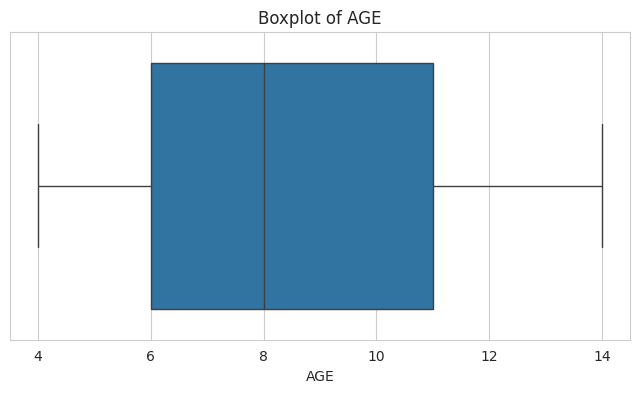

In [19]:
# Outlier detection - Age variable

plt.figure(figsize=(8,4))
sns.boxplot(x=adult_df["AGE"])

plt.title("Boxplot of AGE")
plt.show()

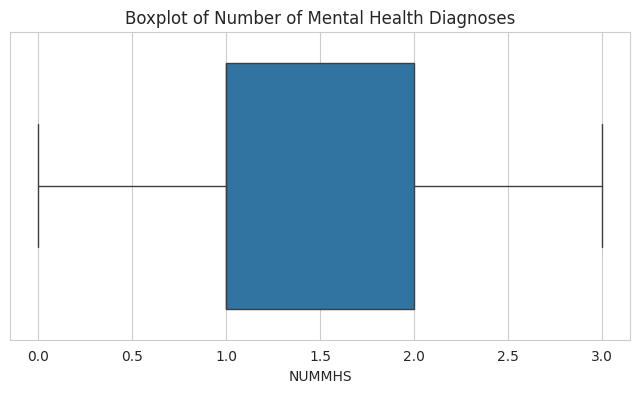

In [20]:
# Outlier detection - NUMMHS variable

plt.figure(figsize=(8,4))
sns.boxplot(x=adult_df["NUMMHS"])

plt.title("Boxplot of Number of Mental Health Diagnoses")
plt.show()

**Data Cleaning Decision continued 3**

Most of the variables to be included as feature varbiables are categorical. This means presence of outliers in the feature sets would rare. Age variable in this dataset is also categorical- an ordinal category. This leaves the NUMMHS variable as the only feature variable that could have an outlier.

**Note: Box plot output above**

Neither Age nor NUMMHS variables have outliers.

**Data Cleaning Decisions continued 4**

**Create a new variable**

Create a new employment status variable, "EMPLOY_STATUS". EMPLOY option 5 (not in labor force) is the same detailed in DETNLF variable. Instead of having two redundant variables, create a new variable that has all the options included.


**New variable code**

Full-time (1), Part-time (2), Employed - full-time/pert-time not differentiated (3), Unemployed (4), Retired/Disabled (5), Student (6), Homemaker (7), Sheltered/non-competitive employment (8), other not in labor force (9).

**Feature Engineering**


**Create a new Employment Feature Variable EMPLOY_STATUS**

In [21]:
# Create new employemnt status variable

adult_df["EMPLOY_STATUS"] = np.where(
    adult_df["EMPLOY"] != 5,
    adult_df["EMPLOY"],
    adult_df["DETNLF"] + 4
)



In [22]:
# Verify newly created employment status variable

adult_df["EMPLOY_STATUS"].value_counts(dropna=False)

,count
EMPLOY_STATUS,
NaN,2400870
4.0,732690
5.0,481846
9.0,420327
1.0,417678
2.0,195580
3.0,128065
6.0,108102
7.0,37241


**Data Decisions continued 5**

Drop all identified variables that would not be included.

In [23]:
# Drop columns of variables to be removed from ML

drop_cols = [
    "YEAR",
    "CASEID",
    "SMISED",

    "MH1",
    "MH2",
    "MH3",
    "SUB",

    "CONDUCTFLG",
    "ODDFLG",
    "PDDFLG",
    "DELIRDEMFLG",

    "EMPLOY",
    "DETNLF"
]

model_df = adult_df.drop(columns=drop_cols)

In [24]:
# Verify variable drop from above

model_df.shape


(4931359, 29)

In [25]:
# Verify retained variable names

model_df.columns.tolist()

['AGE',
 'EDUC',
 'ETHNIC',
 'RACE',
 'SPHSERVICE',
 'CMPSERVICE',
 'OPISERVICE',
 'RTCSERVICE',
 'IJSSERVICE',
 'MARSTAT',
 'SAP',
 'VETERAN',
 'LIVARAG',
 'NUMMHS',
 'TRAUSTREFLG',
 'ANXIETYFLG',
 'ADHDFLG',
 'BIPOLARFLG',
 'DEPRESSFLG',
 'PERSONFLG',
 'SCHIZOFLG',
 'ALCSUBFLG',
 'OTHERDISFLG',
 'STATEFIP',
 'DIVISION',
 'REGION',
 'SEX',
 'SMI',
 'EMPLOY_STATUS']

In [26]:
# verify the structure of model_df

model_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4931359 entries, 0 to 7213555
Data columns (total 29 columns):
 #   Column         Dtype  
---  ------         -----  
 0   AGE            int64  
 1   EDUC           float64
 2   ETHNIC         float64
 3   RACE           float64
 4   SPHSERVICE     int64  
 5   CMPSERVICE     int64  
 6   OPISERVICE     int64  
 7   RTCSERVICE     int64  
 8   IJSSERVICE     int64  
 9   MARSTAT        float64
 10  SAP            float64
 11  VETERAN        float64
 12  LIVARAG        float64
 13  NUMMHS         int64  
 14  TRAUSTREFLG    int64  
 15  ANXIETYFLG     int64  
 16  ADHDFLG        int64  
 17  BIPOLARFLG     int64  
 18  DEPRESSFLG     int64  
 19  PERSONFLG      int64  
 20  SCHIZOFLG      int64  
 21  ALCSUBFLG      int64  
 22  OTHERDISFLG    int64  
 23  STATEFIP       int64  
 24  DIVISION       int64  
 25  REGION         int64  
 26  SEX            float64
 27  SMI            int64  
 28  EMPLOY_STATUS  float64
dtypes: float64(9), int6

**Note: above output are the retained target and feature variables**.

**Handling Missing Data - Impute**

In [27]:
# Missingness in retained variables

missing_pct = (model_df.isnull().mean() * 100).round(2)

missing_pct.sort_values(ascending=False)

,0
VETERAN,55.83
EMPLOY_STATUS,48.69
EDUC,47.58
MARSTAT,44.05
LIVARAG,33.69
ETHNIC,12.54
RACE,10.76
SAP,6.94
SEX,0.11
IJSSERVICE,0.00


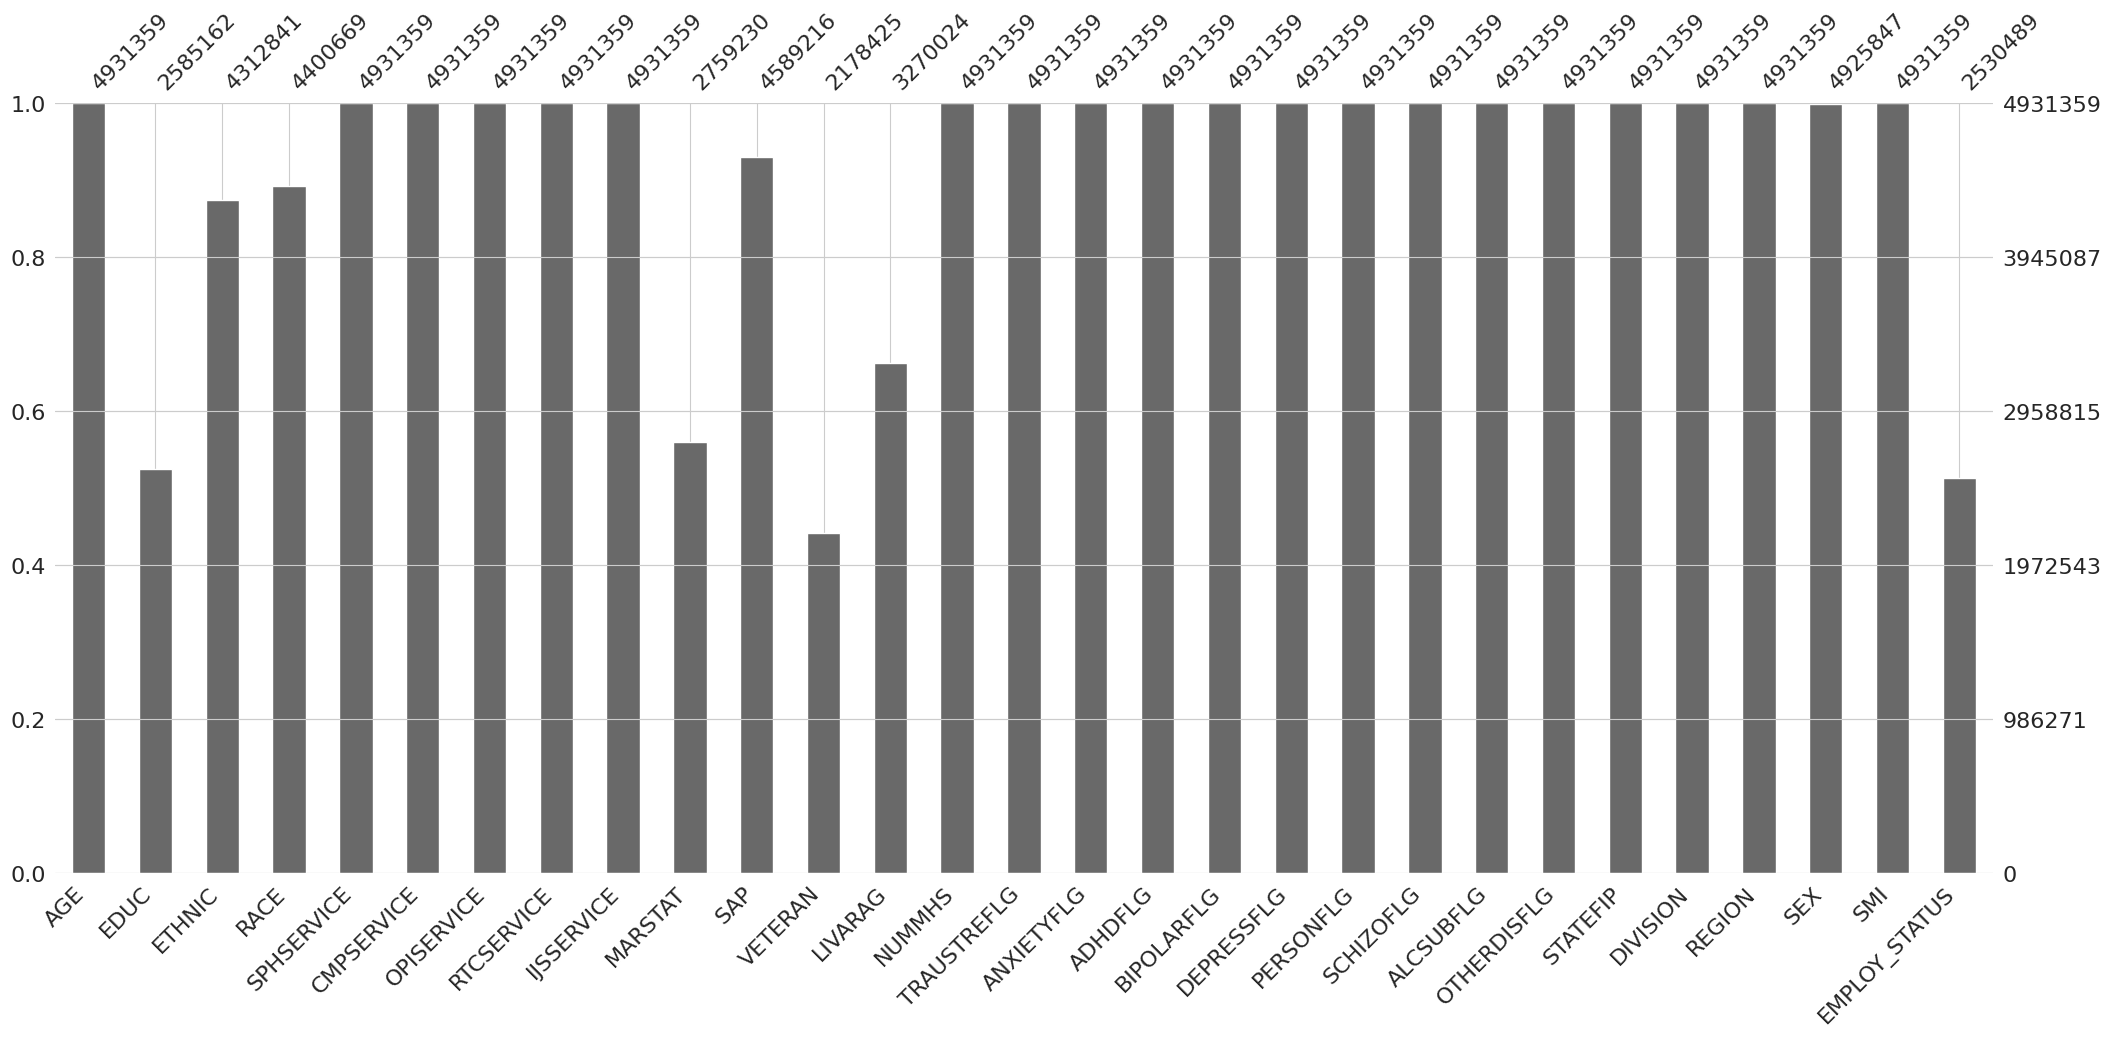

In [28]:
# Nullity - Bar Chart of the number of Null, or NaN values in a feature

msno.bar(model_df)
plt.show()

In [29]:
# Missingness above 50% per row

row_missing_pct = model_df.isnull().mean(axis=1) * 100

print((row_missing_pct > 50).mean() * 100)

0.0


**Missing Data Decisions**

**Codebook referenced**: Missing data code (-9) could be Missing/unknown/not collected/invalid.

**No row deletion needed**: Missingness is concentrated within features and not within the individual client record of people who accessed publicly funded mental health care. These feature sets have meaningful relationship with the Target variable so we will be keeping them.

**Decision**

Since we are unsure whether the data is truly missing, unknown, not collected by the agencies, or invalid, making data imputation decisions is difficult. Instead of imputing data based on frequency of occurrence or mean/median values (which is meaningless in a categorical variable). We will keep the missing data as a category within the nominal feature variables and input the most frequent data for the ordinal features category.

**Variable Classification Table**

In [30]:
# Variable Classification - Binary features

binary_features = [
    "SPHSERVICE",
    "CMPSERVICE",
    "OPISERVICE",
    "RTCSERVICE",
    "IJSSERVICE",
    "TRAUSTREFLG",
    "ANXIETYFLG",
    "ADHDFLG",
    "BIPOLARFLG",
    "DEPRESSFLG",
    "PERSONFLG",
    "SCHIZOFLG",
    "ALCSUBFLG",
    "OTHERDISFLG"
]


In [31]:
# Variable classification - Ordinal features

ordinal_features = [
    "AGE",
    "EDUC",
    "NUMMHS"
]


In [32]:
# Variable classification - Nominal features
# Sex, Veteran, SAP (originally binary features but due to missingness, will have a 3rd category of missing value)

nominal_features = [
    "SEX",
    "RACE",
    "ETHNIC",
    "MARSTAT",
    "SAP",
    "VETERAN",
    "LIVARAG",
    "EMPLOY_STATUS",
]


In [33]:
# Variable classification - Geo features

geo_features = [
    "STATEFIP",
    "DIVISION",
    "REGION"
]



In [34]:
# Check all features appears together

all_features = (
    binary_features +
    ordinal_features +
    nominal_features +
    geo_features
)

len(all_features), len(set(all_features))

(28, 28)

In [35]:
# Confirm feature coding - Binary

len(binary_features)


14

In [36]:
# Confirm feature coding - Ordinal

len(ordinal_features)


3

In [37]:
# Confirm feature coding - Nominal

len(nominal_features)


8

In [38]:
# Confirm feature coding - Geo

len(geo_features)

3

In [39]:
# Feature validation

sorted(all_features)

['ADHDFLG',
 'AGE',
 'ALCSUBFLG',
 'ANXIETYFLG',
 'BIPOLARFLG',
 'CMPSERVICE',
 'DEPRESSFLG',
 'DIVISION',
 'EDUC',
 'EMPLOY_STATUS',
 'ETHNIC',
 'IJSSERVICE',
 'LIVARAG',
 'MARSTAT',
 'NUMMHS',
 'OPISERVICE',
 'OTHERDISFLG',
 'PERSONFLG',
 'RACE',
 'REGION',
 'RTCSERVICE',
 'SAP',
 'SCHIZOFLG',
 'SEX',
 'SPHSERVICE',
 'STATEFIP',
 'TRAUSTREFLG',
 'VETERAN']

In [40]:
# Feature validation compared to initial retained feature list

sorted(model_df.drop("SMI", axis=1).columns.tolist())

['ADHDFLG',
 'AGE',
 'ALCSUBFLG',
 'ANXIETYFLG',
 'BIPOLARFLG',
 'CMPSERVICE',
 'DEPRESSFLG',
 'DIVISION',
 'EDUC',
 'EMPLOY_STATUS',
 'ETHNIC',
 'IJSSERVICE',
 'LIVARAG',
 'MARSTAT',
 'NUMMHS',
 'OPISERVICE',
 'OTHERDISFLG',
 'PERSONFLG',
 'RACE',
 'REGION',
 'RTCSERVICE',
 'SAP',
 'SCHIZOFLG',
 'SEX',
 'SPHSERVICE',
 'STATEFIP',
 'TRAUSTREFLG',
 'VETERAN']

**Machine Learning Phase**



**Decisions**

The model crashed due to using all available RAM. Reduce model size to 200,000 rows.





In [41]:
# Reduce machine model sample size for training

sample_smi_1 = model_df[model_df["SMI"] == 1].sample(n=100000, random_state=42)
sample_smi_0 = model_df[model_df["SMI"] == 0].sample(n=100000, random_state=42)

model_sample = pd.concat([sample_smi_1, sample_smi_0], axis=0)

model_sample = model_sample.sample(frac=1, random_state=42).reset_index(drop=True)

model_sample.shape

(200000, 29)

In [42]:
# Separate the Target and Feature sets into X and Y (X- feature, Y- target)
# Drop the SMI column from the dataset to avoid data leakage

X = model_sample.drop("SMI", axis=1)
y = model_sample["SMI"]

In [43]:
# Verify Target and Feature separation

print(X.shape)
print(y.shape)

(200000, 28)
(200000,)


**Data Split Notes**

1. Split data into an 80/20 ratio (Training/Testing)

2. Use the same random split every time (Random_state = 42) to improve reproducibilty

3. Stratify the target variable due to an imbalance in SMI and Not-SMI proportions (73% to 27%) to preserve them.



In [44]:
#Split Data into Training and Testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [45]:
# Check the split-up dataset for X and Y

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (160000, 28)
X_test: (40000, 28)
y_train: (160000,)
y_test: (40000,)


In [46]:
# Class balance check after splitting Y (Is the distribution balanced?)
# stratify output

print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
SMI
0    50.0
1    50.0
Name: proportion, dtype: float64

Testing target distribution:
SMI
1    50.0
0    50.0
Name: proportion, dtype: float64


**Build Feature Transformer Pipelines**

**Ordinal Transformer**: Fill in missing values based on the frequency of occurrence.

**Nominal Transformer**: Create missing category and complete One-hot encoding (E.g Veteran_Yes, Veteran_No, Veteran_Missing).

**Column Transformer**: Combines all into a single preprocessing workflow.



In [47]:
# Build Ordinal and Nominal transformers

# =========================
# Ordinal Variables
# =========================

ordinal_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]
)

# =========================
# Nominal Variables
# =========================

nominal_transformer = Pipeline(
    steps=[
        (
            "to_string",
            FunctionTransformer(
                lambda x: x.astype(str),
                feature_names_out="one-to-one"
            )
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [48]:
# Check Ordinal and Nominal transformer output

type(ordinal_transformer)

type(nominal_transformer)

sklearn.pipeline.Pipeline

In [49]:
# Combine Processing Steps

preprocessor = ColumnTransformer(
    transformers=[
        ("ordinal", ordinal_transformer, ordinal_features),
        ("nominal", nominal_transformer, nominal_features),
        ("binary", "passthrough", binary_features)
    ]
)


In [50]:
# Verify combined preprocessor

print(type(preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


**Modeling Phase**

In [51]:
# Libraries for modelling

# =========================
# Modeling
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier


**Question 1: Can we predict SMI from individual demographic, clinical, and service variables?**

**Model 1 - Logistic Regression**

In [52]:
# Build Model Pipeline - Logistic Regression

log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

In [53]:
# Train the Logistic Regression Model created

log_reg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['AGE', 'EDUC', 'NUMMHS']),
                                                 ('nominal',
                                                  Pipeline(steps=[('to_string',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<function <lambda> at 0x784c9d49db20>)),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'...
                                                   'MARSTAT', 'SAP', 'VETERAN',
                                                   'LIVARAG',
                                                   'EMPLOY_STATUS']),
                                                 ('binary', 'passthrough',
                                                  ['SPHSERVICE', 'CMPSERVICE',
                                                   'OPISERVICE', 'RTCSERVICE',
                                                   'IJSSERVICE', 'TRAUSTREFLG',
                                                   'ANXIETYFLG', 'ADHDFLG',
                                                   'BIPOLARFLG', 'DEPRESSFLG',
                                                   'PERSONFLG', 'SCHIZOFLG',
                                                   'ALCSUBFLG',
                                                   'OTHERDISFLG'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [54]:
# Model Evaluation

# Predictions

y_pred = log_reg_model.predict(X_test)

y_prob = log_reg_model.predict_proba(X_test)[:, 1]

In [55]:
# Model Performance

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.694575
Precision: 0.6974679048053991
Recall: 0.68725
F1 Score: 0.6923212531795402
ROC AUC: 0.7506923262499999


In [56]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[14038  5962]
 [ 6255 13745]]


In [57]:
# Classification report of the Logistic Regression Model

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.70      0.70     20000
           1       0.70      0.69      0.69     20000

    accuracy                           0.69     40000
   macro avg       0.69      0.69      0.69     40000
weighted avg       0.69      0.69      0.69     40000



**Logistic Regression Model Output**

**Accuracy**: Out of every 100 clients, the model correctly classifies about a 70% them.

**ROC-AUC**: The probability that the model would rank client with SMI higher than client with non-SMI is a 75%

**Precision**: Prediction of clients with SMI is about 70% accuracy. That is 70% of the people prdicted as SMI were actually diagmosed SMI.

**Recall**: Model had about 69% recall rate of actual SMI clients. A higher recall rate means fewer vulnerable or at risks clients are missed.

**F1 Score**: At 69%, the model is fairly balanced and not over fitted.

**Note**: Logistic Regression assumes there is a linear relationship among the features and the target. However, this is not the practical reality when it comes to mental health.

**Takeaways**
1. SMI is not random. A pattern exist in the data. Administrative and clinical characteristics are strongly associated with SMI status.

2. Out of the 20,000 actual SMI clients, the model identified 13.745 SMI clients correctly and missed 6.255 clients who were actually SMI clients but predicted not SMI clients (Results from the confusion Matrix).

**Logistic Regression Findings**

Logistic Regression served as the baseline predictive model for identifying Serious Mental Illness (SMI) among adults receiving public mental health services. The model achieved an ROC-AUC of 0.751, indicating moderate discriminatory ability. Precision (0.70) and recall (0.69) were well balanced, suggesting the model effectively distinguished between SMI and non-SMI clients without favoring one class excessively. These results demonstrate that routinely collected demographic, service utilization, and diagnostic variables contain meaningful information for identifying individuals with SMI.

**Model 2 - Random Forest**

In [58]:
# Build Model Pipeline - Random Forest

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [59]:
# Train Random Forest model created

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['AGE', 'EDUC', 'NUMMHS']),
                                                 ('nominal',
                                                  Pipeline(steps=[('to_string',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<function <lambda> at 0x784c9d49db20>)),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'...
                                                  ['SEX', 'RACE', 'ETHNIC',
                                                   'MARSTAT', 'SAP', 'VETERAN',
                                                   'LIVARAG',
                                                   'EMPLOY_STATUS']),
                                                 ('binary', 'passthrough',
                                                  ['SPHSERVICE', 'CMPSERVICE',
                                                   'OPISERVICE', 'RTCSERVICE',
                                                   'IJSSERVICE', 'TRAUSTREFLG',
                                                   'ANXIETYFLG', 'ADHDFLG',
                                                   'BIPOLARFLG', 'DEPRESSFLG',
                                                   'PERSONFLG', 'SCHIZOFLG',
                                                   'ALCSUBFLG',
                                                   'OTHERDISFLG'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [60]:
# Model Evaluation

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [61]:
# Model Performance

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.757875
Precision: 0.7537265705711615
Recall: 0.76605
F1 Score: 0.7598383217199395
ROC AUC: 0.8374153200000001


**Random Forest Model Output**

**Accuracy**: Improved from about 70% in Logistic Reg. Model to 76% in this Model.

**ROC-AUC**: This improved from a 75% in the Logistic Reg. Model to 84% in this Model

**Precision**: Improved from 70% in the baseline model to 75% in this Model

**Recall**: Improved from 69% in the baseline model to 77% in this model

**F1 Score**: Improved from a 69% in the baseline model to 76% in this model.

**Note**: Random Forest performance compared to the baseline Logistic Regression performance suggests that non-linear relationships, interactions, and decision rule patterns exist in the MH-CLD dataset.

**Takeaway**: SMI prediction appears to depend on the complex interactions among demographic, service utilization, and clinical characteristics of clients.

Improved recall rate within behavioral health means the model found 77% of actual SMI clients, which can translate to agencies providing earlier interventions, improved resource allocation, and improved case management prioritization for at risks clients.

**Random Forest Findings**

Random Forest substantially outperformed Logistic Regression across all evaluation metrics. The model achieved an ROC-AUC of 0.837, indicating strong discriminatory ability between SMI and non-SMI clients. Recall improved from 68.7% to 76.6%, suggesting that nonlinear relationships and interactions among demographic, service utilization, and diagnostic variables contribute meaningfully to the identification of Serious Mental Illness. These findings support the use of ensemble machine learning approaches for population-level mental health risk stratification.

**Feature Importance Analysis**

What are the actionable insights from the Random Forest Model?

Which Feature variables and interactions are the most influential in identifying SMI?

In [62]:
# Confirm no of features retained after One-Hot Encoding and

feature_names = (
    rf_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of model features:", len(feature_names))

Number of model features: 57


In [63]:
# Extract Feature Importance Classification

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.named_steps["classifier"].feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
0,ordinal__AGE,0.178266
1,ordinal__EDUC,0.060504
2,ordinal__NUMMHS,0.056186
52,binary__DEPRESSFLG,0.046526
54,binary__SCHIZOFLG,0.046249
51,binary__BIPOLARFLG,0.035097
22,nominal__MARSTAT_nan,0.026336
49,binary__ANXIETYFLG,0.023412
42,nominal__EMPLOY_STATUS_nan,0.020899
23,nominal__SAP_1.0,0.019636


**Feature Importance Output**

1. Age is the most important feature. Clinically, only adults can be classified SMI.

2. The third most influential feature, NUMMHS, is the number of diagnoses reported per client.

3. Diagnosis flags were not surprising predictors on the feature importance list.

4. Interesting variables are the "NaN" (missing) variables that appear to be influential in the prediction of SMI.

5. Race_5.0 (White) is an interesting but not shocking find.

**Model 3 - Gradient Boosting**

In [64]:
# Build Model Pipeline - Gradient Boosting

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

In [65]:
# Train model created -Gradient Boosting

gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['AGE', 'EDUC', 'NUMMHS']),
                                                 ('nominal',
                                                  Pipeline(steps=[('to_string',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<function <lambda> at 0x784c9d49db20>)),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['SEX', 'RACE', 'ETHNIC',
                                                   'MARSTAT', 'SAP', 'VETERAN',
                                                   'LIVARAG',
                                                   'EMPLOY_STATUS']),
                                                 ('binary', 'passthrough',
                                                  ['SPHSERVICE', 'CMPSERVICE',
                                                   'OPISERVICE', 'RTCSERVICE',
                                                   'IJSSERVICE', 'TRAUSTREFLG',
                                                   'ANXIETYFLG', 'ADHDFLG',
                                                   'BIPOLARFLG', 'DEPRESSFLG',
                                                   'PERSONFLG', 'SCHIZOFLG',
                                                   'ALCSUBFLG',
                                                   'OTHERDISFLG'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [66]:
# Model Evaluation

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]


In [67]:
# Model Performnace

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_gb))

Accuracy: 0.734475
Precision: 0.7326948841363569
Recall: 0.7383
F1 Score: 0.7354867631310238
ROC AUC: 0.8003790225


**Gradient Boosting Model Output**

**Note**: The Gradient Boosting model outperformed the Logistic Regression model but was outperformed by the Random Forest model.

**Takeaway**: This means nonlinear interactions substantially improve prediction in this dataset. Tuning the Gradient Boosting model parameters may improve performance.




**Model 4 - Neural Network**

**Note**: Hidden layer sizes (32, 16) - The first layer is created with 32 neurons while the second layer is created with 16 neurons.

max_iter=100 (limits training cycles to avoid Colab running continuously for long)

In [68]:
# Build Neural Network transformer
# Scale ordinal features to compete evenly with other features.

nn_preprocessor = ColumnTransformer(
    transformers=[
        (
            "ordinal",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("scaler", StandardScaler())
                ]
            ),
            ordinal_features
        ),

        (
            "nominal",
            Pipeline(
                steps=[
                    (
                        "to_string",
                        FunctionTransformer(
                            lambda x: x.astype(str),
                            feature_names_out="one-to-one"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore")
                    )
                ]
            ),
            nominal_features
        ),

        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

In [69]:
# Build Model pipeline - Neural Network

nn_model = Pipeline(
    steps=[
        ("preprocessor", nn_preprocessor),
        ("classifier", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            max_iter=100,
            random_state=42
        ))
    ]
)

In [70]:
# Train built model - Neural Network

nn_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['AGE', 'EDUC', 'NUMMHS']),
                                                 ('nominal',
                                                  Pipeline(steps=[('to_string',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<function <lambda> at 0x784c9bbb8360>)),
                                                                  ('onehot',
                                                                   OneHotEnc...
                                                  ['SEX', 'RACE', 'ETHNIC',
                                                   'MARSTAT', 'SAP', 'VETERAN',
                                                   'LIVARAG',
                                                   'EMPLOY_STATUS']),
                                                 ('binary', 'passthrough',
                                                  ['SPHSERVICE', 'CMPSERVICE',
                                                   'OPISERVICE', 'RTCSERVICE',
                                                   'IJSSERVICE', 'TRAUSTREFLG',
                                                   'ANXIETYFLG', 'ADHDFLG',
                                                   'BIPOLARFLG', 'DEPRESSFLG',
                                                   'PERSONFLG', 'SCHIZOFLG',
                                                   'ALCSUBFLG',
                                                   'OTHERDISFLG'])])),
                ('classifier',
                 MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=100,
                               random_state=42))])

In [71]:
# Model Evaluation

y_pred_nn = nn_model.predict(X_test)

y_prob_nn = nn_model.predict_proba(X_test)[:,1]

In [72]:
# Model Performance

print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Precision:", precision_score(y_test, y_pred_nn))
print("Recall:", recall_score(y_test, y_pred_nn))
print("F1 Score:", f1_score(y_test, y_pred_nn))
print("ROC AUC:", roc_auc_score(y_test, y_prob_nn))

Accuracy: 0.778
Precision: 0.7593283582089553
Recall: 0.814
F1 Score: 0.7857142857142857
ROC AUC: 0.86261257625


In [73]:
# Confusion Matrix

print(confusion_matrix(y_test, y_pred_nn))

print(classification_report(y_test, y_pred_nn))

[[14840  5160]
 [ 3720 16280]]
              precision    recall  f1-score   support

           0       0.80      0.74      0.77     20000
           1       0.76      0.81      0.79     20000

    accuracy                           0.78     40000
   macro avg       0.78      0.78      0.78     40000
weighted avg       0.78      0.78      0.78     40000



**Neural Network Model Output**

**Note**: The neural network model outperformed all previous models with AUC of 86%. Additionally, the recall rate is 81.4%, which is important in this healthcare dataset. This means fewer missed predictions of SMI cases. True positives of correctly predicted SMI cases is 16280/20000.

**Takeaway**: Latent nonlinear patterns are influential in the prediction of SMI. "SMI classification appears to arise from complex nonlinear combinations of demographic, clinical, and service-utilization characteristics that are not fully captured by traditional linear approaches."


**Question 2 - Does geography provide additional predictive information beyond individual characteristics?**

Robustness/Sensitivity Test using Geo-Features.**

**Aim**: To evaluate if geographic factors contribute additional predictive value to the models.

In [74]:
# Check Dataset

model_sample.columns.tolist()

['AGE',
 'EDUC',
 'ETHNIC',
 'RACE',
 'SPHSERVICE',
 'CMPSERVICE',
 'OPISERVICE',
 'RTCSERVICE',
 'IJSSERVICE',
 'MARSTAT',
 'SAP',
 'VETERAN',
 'LIVARAG',
 'NUMMHS',
 'TRAUSTREFLG',
 'ANXIETYFLG',
 'ADHDFLG',
 'BIPOLARFLG',
 'DEPRESSFLG',
 'PERSONFLG',
 'SCHIZOFLG',
 'ALCSUBFLG',
 'OTHERDISFLG',
 'STATEFIP',
 'DIVISION',
 'REGION',
 'SEX',
 'SMI',
 'EMPLOY_STATUS']

In [75]:
# Add Geo-Features back to initial variable list
# Add features to Nominal features


nominal_features = [
    "SEX",
    "RACE",
    "ETHNIC",
    "MARSTAT",
    "SAP",
    "VETERAN",
    "LIVARAG",
    "EMPLOY_STATUS",
    "STATEFIP",
    "DIVISION",
    "REGION"
]

**Model 5 Comparison Neural Network Model - Geo Features**

In [76]:
# Build Neural Network transformer
# Scale ordinal features to compete evenly with other features.

nn_preprocessor = ColumnTransformer(
    transformers=[
        (
            "ordinal",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("scaler", StandardScaler())
                ]
            ),
            ordinal_features
        ),

        (
            "nominal",
            Pipeline(
                steps=[
                    (
                        "to_string",
                        FunctionTransformer(
                            lambda x: x.astype(str),
                            feature_names_out="one-to-one"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore")
                    )
                ]
            ),
            nominal_features
        ),

        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

In [77]:
# Build Model pipeline - Neural Network

nn_model = Pipeline(
    steps=[
        ("preprocessor", nn_preprocessor),
        ("classifier", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            max_iter=100,
            random_state=42
        ))
    ]
)

In [78]:
# Train built model - Neural Network

nn_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['AGE', 'EDUC', 'NUMMHS']),
                                                 ('nominal',
                                                  Pipeline(steps=[('to_string',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<function <lambda> at 0x784c9bbba0c0>)),
                                                                  ('onehot',
                                                                   OneHotEnc...
                                                   'LIVARAG', 'EMPLOY_STATUS',
                                                   'STATEFIP', 'DIVISION',
                                                   'REGION']),
                                                 ('binary', 'passthrough',
                                                  ['SPHSERVICE', 'CMPSERVICE',
                                                   'OPISERVICE', 'RTCSERVICE',
                                                   'IJSSERVICE', 'TRAUSTREFLG',
                                                   'ANXIETYFLG', 'ADHDFLG',
                                                   'BIPOLARFLG', 'DEPRESSFLG',
                                                   'PERSONFLG', 'SCHIZOFLG',
                                                   'ALCSUBFLG',
                                                   'OTHERDISFLG'])])),
                ('classifier',
                 MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=100,
                               random_state=42))])

In [79]:
# Confirm Feature count after retraining and one-hot encoding

feature_names = (
    nn_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

print(len(feature_names))

123


In [80]:
# Model Evaluation

y_pred_nn = nn_model.predict(X_test)

y_prob_nn = nn_model.predict_proba(X_test)[:,1]

# Model Performance

print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Precision:", precision_score(y_test, y_pred_nn))
print("Recall:", recall_score(y_test, y_pred_nn))
print("F1 Score:", f1_score(y_test, y_pred_nn))
print("ROC AUC:", roc_auc_score(y_test, y_prob_nn))

Accuracy: 0.84435
Precision: 0.8544153972828324
Recall: 0.83015
F1 Score: 0.8421079326435382
ROC AUC: 0.92654747875


In [81]:
# Confusion Matrix

print(confusion_matrix(y_test, y_pred_nn))

print(classification_report(y_test, y_pred_nn))

[[17171  2829]
 [ 3397 16603]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.85     20000
           1       0.85      0.83      0.84     20000

    accuracy                           0.84     40000
   macro avg       0.84      0.84      0.84     40000
weighted avg       0.84      0.84      0.84     40000



**Comaprison Neural Network Model Output**

**Note**: The new neural network model outperformed all previous models with AUC of 93%. Additionally, the recall rate is 83%, which is important in this healthcare dataset. This means fewer missed predictions of SMI cases. True positives of correctly predicted SMI cases is 16603/20000.

**Takeaway**: Geo-Features contributed susbtantially to the predictive value of the feature sets by increasing the model performance by 604% points compared to the initail neural network model without the geo-features.


**Model 6 Comparison Random Forest Model - Geo Features**

In [82]:
# Check Nominal Features list

print(nominal_features)

['SEX', 'RACE', 'ETHNIC', 'MARSTAT', 'SAP', 'VETERAN', 'LIVARAG', 'EMPLOY_STATUS', 'STATEFIP', 'DIVISION', 'REGION']


In [83]:
# Verify Transformer Existence

print(type(ordinal_transformer))
print(type(nominal_transformer))

<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.pipeline.Pipeline'>


In [84]:
# Binary Transformer

binary_transformer = "passthrough"

In [85]:
# Rebuild Preprocessor - Comparison Random Forest

preprocessor = ColumnTransformer(
    transformers=[
        ("ordinal", ordinal_transformer, ordinal_features),
        ("nominal", nominal_transformer, nominal_features),
        ("binary", binary_transformer, binary_features)
    ]
)

In [86]:
# Build Model Pipeline - Random Forest

rf_model_geo = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [87]:
# Retrain Model- comparison Random Forest

rf_model_geo.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['AGE', 'EDUC', 'NUMMHS']),
                                                 ('nominal',
                                                  Pipeline(steps=[('to_string',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<function <lambda> at 0x784c9d49db20>)),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'...
                                                   'MARSTAT', 'SAP', 'VETERAN',
                                                   'LIVARAG', 'EMPLOY_STATUS',
                                                   'STATEFIP', 'DIVISION',
                                                   'REGION']),
                                                 ('binary', 'passthrough',
                                                  ['SPHSERVICE', 'CMPSERVICE',
                                                   'OPISERVICE', 'RTCSERVICE',
                                                   'IJSSERVICE', 'TRAUSTREFLG',
                                                   'ANXIETYFLG', 'ADHDFLG',
                                                   'BIPOLARFLG', 'DEPRESSFLG',
                                                   'PERSONFLG', 'SCHIZOFLG',
                                                   'ALCSUBFLG',
                                                   'OTHERDISFLG'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [88]:
# Model Evaluation

y_pred_rf_geo = rf_model_geo.predict(X_test)
y_prob_rf_geo = rf_model_geo.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf_geo))
print("Precision:", precision_score(y_test, y_pred_rf_geo))
print("Recall:", recall_score(y_test, y_pred_rf_geo))
print("F1 Score:", f1_score(y_test, y_pred_rf_geo))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf_geo))

Accuracy: 0.8269
Precision: 0.8343219472284721
Recall: 0.8158
F1 Score: 0.8249570229547982
ROC AUC: 0.90951636625


In [89]:
# Extract Feature Names

feature_names = (
    rf_model_geo.named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of Features:", len(feature_names))

Number of Features: 123


In [90]:
# Extract Feature Importance Classification

importances = (
    rf_model_geo.named_steps["classifier"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(30)

,Feature,Importance
0,ordinal__AGE,0.117576
2,ordinal__NUMMHS,0.054146
118,binary__DEPRESSFLG,0.045506
1,ordinal__EDUC,0.041691
120,binary__SCHIZOFLG,0.037272
103,nominal__DIVISION_9,0.034939
115,binary__ANXIETYFLG,0.029844
117,binary__BIPOLARFLG,0.029673
81,nominal__STATEFIP_48,0.028278
114,binary__TRAUSTREFLG,0.021596


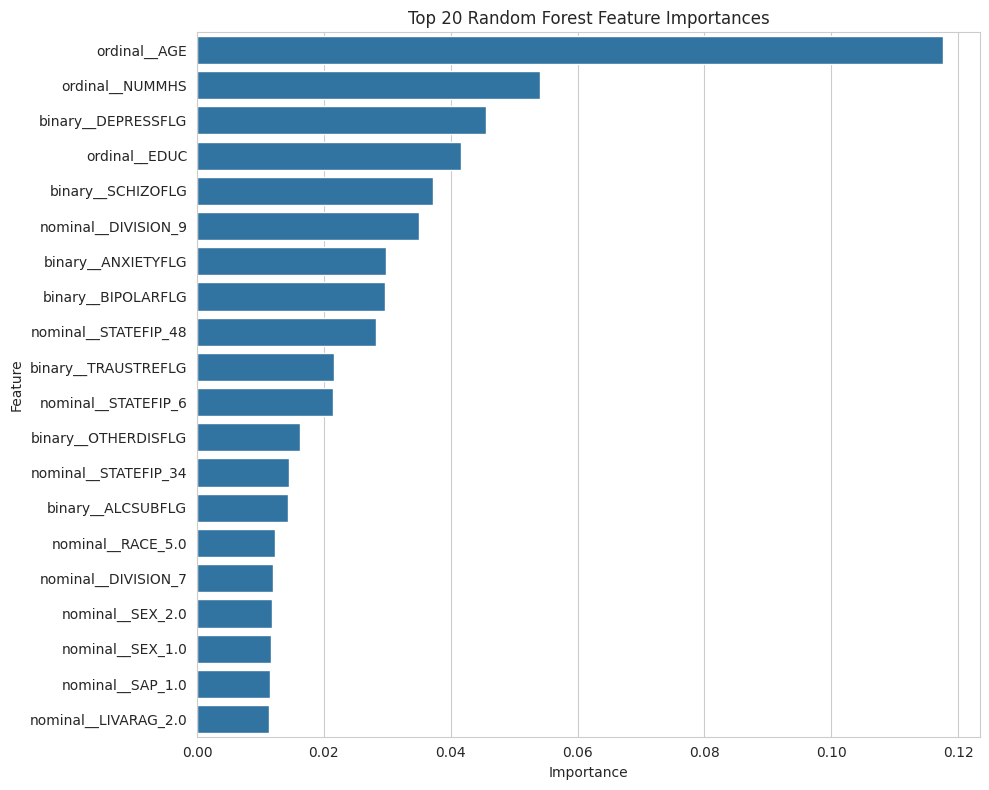

In [91]:
#Visualize top features

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [92]:
# Feature Importance Categories

def categorize_feature(feature):

    if "STATEFIP" in feature or "DIVISION" in feature or "REGION" in feature:
        return "Geography"

    elif any(x in feature for x in [
        "NUMMHS",
        "SAP",
        "TRAUSTREFLG",
        "DEPRESSFLG",
        "SCHIZOFLG",
        "BIPOLARFLG",
        "ANXIETYFLG",
        "ADHDFLG",
        "PERSONFLG",
        "ALCSUBFLG",
        "OTHERDISFLG"
    ]):
        return "Clinical Diagnoses"

    elif any(x in feature for x in [
        "SPHSERVICE",
        "CMPSERVICE",
        "OPISERVICE",
        "RTCSERVICE",
        "IJSSERVICE"
    ]):
        return "Service Factors"

    elif any(x in feature for x in [
        "AGE",
        "SEX",
        "RACE",
        "ETHNIC",
        "EDUC",
        "MARSTAT"
    ]):
        return "Demographics"

    else:
        return "Social Factors"


importance_df["Category"] = importance_df["Feature"].apply(categorize_feature)

# Sum feature importance by category
category_importance = (
    importance_df
    .groupby("Category")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

print(category_importance)

Category
Geography             0.293762
Clinical Diagnoses    0.293009
Demographics          0.281512
Social Factors        0.107641
Service Factors       0.024075
Name: Importance, dtype: float64


**Comparison Random Forest Model Output**

**Note**: The Comparison of Random Forest model clearly outperformed the initial model without geographic characteristics.  

**Takeaway**: This confirms that Geogrpahical characteristics and clinical complexity & Diagnoses, closely followed by demographics are quite influential in predicting SMI. SMI classification appears to be influenced by a combination of geographic context, clinical complexity, and demographic characteristics rather than by any single domain alone.


**Summary of Feature Importance Category findings**

Category-level feature importance analysis revealed that geographic factors (29.4%), clinical complexity and diagnoses (29.3%), and demographic characteristics (28.2%) contributed nearly equal predictive value to SMI classification. Social factors (10.8%) and service-related variables (2.4%) contributed substantially less predictive information.

**Question 3: Are there distinct behavioral health client profiles within the MH-CLD population that can help inform service planning, risk stratification, and future mental health product development?**

**Unsupervised Training Model- K-Means Clustering**

**Goal** - Identify client profiles that can help with service delivery planning

**Model K** (without GeoFeatures) - Behavioral health Segmentation



In [93]:
# Finding the last dataframe name

for var in dir():
    if not var.startswith('_'):
        print(var)

ColumnTransformer
FunctionTransformer
GradientBoostingClassifier
In
KMeans
LogisticRegression
MLPClassifier
OneHotEncoder
Out
Pipeline
RandomForestClassifier
SimpleImputer
StandardScaler
X
X_test
X_train
accuracy_score
adult_df
all_features
binary_features
binary_transformer
categorize_feature
category_importance
classification_report
cm
confusion_matrix
df
diag_flags
drive
drop_cols
exit
f1_score
feature_names
file_path
gb_model
geo_features
geo_summary
geo_vars
get_ipython
importance_df
importances
log_reg_model
missing_pct
missing_percent
model_df
model_sample
msno
nn_model
nn_preprocessor
nominal_features
nominal_transformer
np
ordinal_features
ordinal_transformer
pd
plt
precision_score
preprocessor
quit
recall_score
rf_model
rf_model_geo
roc_auc_score
row_missing_pct
sample_smi_0
sample_smi_1
silhouette_score
sns
socio_vars
summary
temp
top20
train_test_split
var
y
y_pred
y_pred_gb
y_pred_nn
y_pred_rf
y_pred_rf_geo
y_prob
y_prob_gb
y_prob_nn
y_prob_rf
y_prob_rf_geo
y_test
y_train


In [94]:
# Exclude target from clustering

df_model = model_sample.copy()

X_cluster = df_model.drop(columns=['SMI'])
y_smi = df_model['SMI']

print(df_model.shape)
print(X_cluster.shape)
print(y_smi.shape)

(200000, 29)
(200000, 28)
(200000,)


In [95]:
# Confirm Features List

print(X_cluster.columns.tolist())

['AGE', 'EDUC', 'ETHNIC', 'RACE', 'SPHSERVICE', 'CMPSERVICE', 'OPISERVICE', 'RTCSERVICE', 'IJSSERVICE', 'MARSTAT', 'SAP', 'VETERAN', 'LIVARAG', 'NUMMHS', 'TRAUSTREFLG', 'ANXIETYFLG', 'ADHDFLG', 'BIPOLARFLG', 'DEPRESSFLG', 'PERSONFLG', 'SCHIZOFLG', 'ALCSUBFLG', 'OTHERDISFLG', 'STATEFIP', 'DIVISION', 'REGION', 'SEX', 'EMPLOY_STATUS']


In [96]:
# Check if ready for clustering

print("Ready for clustering")

Ready for clustering


**Model K - Behavioral Health Segmentation**

In [97]:
# Verify Feature list

print(binary_features)
print(ordinal_features)
print(nominal_features)

['SPHSERVICE', 'CMPSERVICE', 'OPISERVICE', 'RTCSERVICE', 'IJSSERVICE', 'TRAUSTREFLG', 'ANXIETYFLG', 'ADHDFLG', 'BIPOLARFLG', 'DEPRESSFLG', 'PERSONFLG', 'SCHIZOFLG', 'ALCSUBFLG', 'OTHERDISFLG']
['AGE', 'EDUC', 'NUMMHS']
['SEX', 'RACE', 'ETHNIC', 'MARSTAT', 'SAP', 'VETERAN', 'LIVARAG', 'EMPLOY_STATUS', 'STATEFIP', 'DIVISION', 'REGION']


In [98]:
# Build Model A preprocessor pipeline

# Numeric pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


In [99]:
# Create Feature list and Remove GeoFeatures from Nominal category

numeric_features = binary_features + ordinal_features

categorical_features = [
    col for col in nominal_features
    if col not in ['STATEFIP', 'DIVISION', 'REGION']
]

print(categorical_features)

['SEX', 'RACE', 'ETHNIC', 'MARSTAT', 'SAP', 'VETERAN', 'LIVARAG', 'EMPLOY_STATUS']


In [100]:
# Create Model A Preprocessor

cluster_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [101]:
# Create a Non-Geo dataset

X_cluster_no_geo = X_cluster.drop(
    columns=['STATEFIP', 'DIVISION', 'REGION']
)

X_cluster_prepared = cluster_preprocessor.fit_transform(
    X_cluster_no_geo
)

print(X_cluster_prepared.shape)

(200000, 49)


In [102]:
# Find Optimal K

ks = range(2, 9)

inertia = []
sil_scores = []

for k in ks:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_cluster_prepared)

    inertia.append(km.inertia_)

    sil = silhouette_score(
        X_cluster_prepared,
        labels,
        sample_size=10000,
        random_state=42
    )

    sil_scores.append(sil)

    print(f"K={k}, Silhouette={sil:.4f}")

K=2, Silhouette=0.3928
K=3, Silhouette=0.0910
K=4, Silhouette=0.0988
K=5, Silhouette=0.1309
K=6, Silhouette=0.1404
K=7, Silhouette=0.1784
K=8, Silhouette=0.1383


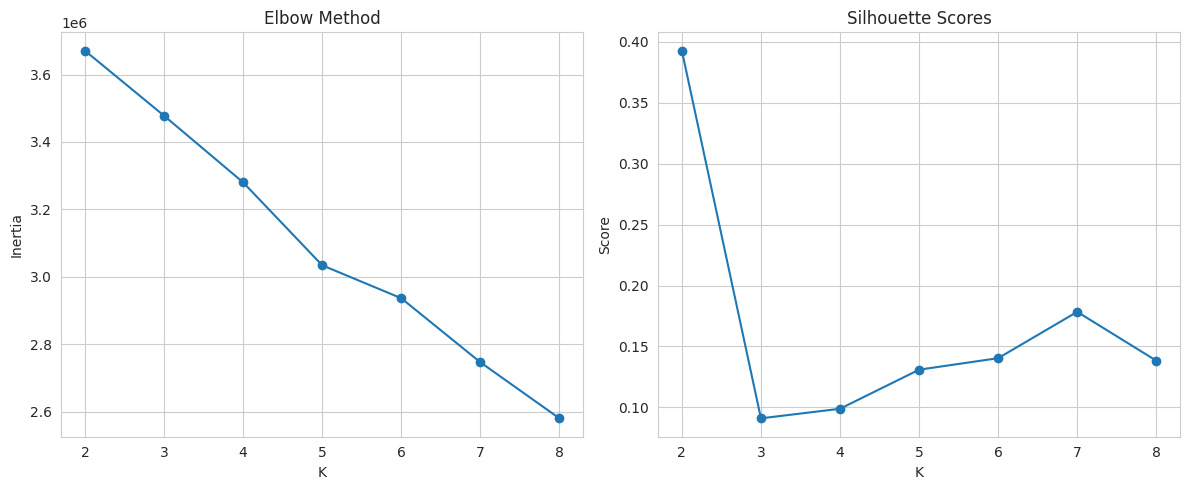

In [103]:
# Plot output

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(ks, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')

plt.subplot(1,2,2)
plt.plot(ks, sil_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('K')
plt.ylabel('Score')

plt.tight_layout()
plt.show()

**Model - K-Clustering Output**

K2 appears to be the best. Two major client population clusters are observed in the data

Elbow plots shows curve starts flattening after K5.

Silhouette plot suggests the client population naturally splits into two clusters; however, when forced, it can split into smaller clusters that may not be well separated.

**Decision**: Run clustering analysis for 2 and sensitivity clustering analysis for 5.

In [104]:
# Primary Clustering 2-Cluster Analysis


kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(
    X_cluster_prepared
)

df_clustered = df_model.copy()
df_clustered['Cluster'] = cluster_labels

In [105]:
# Check cluster sizes
cluster_sizes = df_clustered['Cluster'].value_counts().sort_index()
cluster_percent = df_clustered['Cluster'].value_counts(normalize=True).sort_index() * 100

cluster_summary = pd.DataFrame({
    'Count': cluster_sizes,
    'Percent': cluster_percent
})

cluster_summary

,Count,Percent
Cluster,,
0,13689,6.8445
1,186311,93.1555


In [106]:
# Group Cluster by SMI

smi_profile = df_clustered.groupby('Cluster')['SMI'].agg(['count', 'mean'])
smi_profile['SMI_Rate_Percent'] = smi_profile['mean'] * 100

smi_profile

,count,mean,SMI_Rate_Percent
Cluster,,,
0,13689,0.642998,64.299803
1,186311,0.489493,48.949337


In [107]:
# Cluster profiling - Demographic

# Numeric demographic variables
demo_numeric = ['AGE', 'EDUC']

df_clustered.groupby('Cluster')[demo_numeric].mean()


,AGE,EDUC
Cluster,,
0,8.668712,3.779281
1,8.774061,3.790615


In [108]:
# Cluster profiling - Demographic 2

# Categorical demographic variables
demo_categorical = ['SEX', 'RACE', 'ETHNIC', 'MARSTAT']

for var in demo_categorical:
    print("\n" + "="*50)
    print(f"{var} distribution by cluster (%)")
    print("="*50)

    display(
        pd.crosstab(
            df_clustered['Cluster'],
            df_clustered[var],
            normalize='index'
        ) * 100
    )


SEX distribution by cluster (%)


SEX,1.0,2.0
Cluster,,
0,62.314388,37.685612
1,44.399957,55.600043



RACE distribution by cluster (%)


RACE,1.0,2.0,3.0,4.0,5.0,6.0
Cluster,,,,,,
0,2.227820,1.905062,23.262222,0.322758,62.095568,10.18657
1,2.741166,1.747769,19.454090,0.339895,67.072380,8.64470



ETHNIC distribution by cluster (%)


ETHNIC,1.0,2.0,3.0,4.0
Cluster,,,,
0,0.453001,1.156771,14.309982,84.080246
1,0.711988,0.506619,19.096870,79.684523



MARSTAT distribution by cluster (%)


MARSTAT,1.0,2.0,3.0,4.0
Cluster,,,,
0,73.209017,9.866635,4.508439,12.415909
1,64.662437,15.715350,5.148000,14.474212


In [109]:
# Cluster profiling - Clinical Complexity & Diagnoses

clinical_vars = [
    'TRAUSTREFLG',
    'ANXIETYFLG',
    'ADHDFLG',
    'BIPOLARFLG',
    'DEPRESSFLG',
    'PERSONFLG',
    'SCHIZOFLG',
    'ALCSUBFLG',
    'OTHERDISFLG'
]

clinical_profile = df_clustered.groupby('Cluster')[clinical_vars].mean() * 100

clinical_profile

,TRAUSTREFLG,ANXIETYFLG,ADHDFLG,BIPOLARFLG,DEPRESSFLG,PERSONFLG,SCHIZOFLG,ALCSUBFLG,OTHERDISFLG
Cluster,,,,,,,,,
0,11.629776,11.016144,1.672876,13.704434,24.041201,3.506465,30.601213,10.979619,12.389510
1,20.443774,27.979561,6.009307,11.063222,28.010692,2.687442,10.653155,8.042467,13.601451


In [110]:
# Cluster profiling - Clinical Complexity & Diagnoses (SAP) - Categorical

clinical_categorical_vars = [
    'SAP'
]
for var in clinical_categorical_vars:

    print("\n" + "="*60)
    print(f"{var} distribution by cluster (%)")
    print("="*60)

display(
        pd.crosstab(
            df_clustered['Cluster'],
            df_clustered[var],
            normalize='index'
        ) * 100
    )


SAP distribution by cluster (%)


SAP,1.0,2.0
Cluster,,
0,70.667414,29.332586
1,42.561762,57.438238


In [111]:
# Cluster profiling - Clinical Complexity & Diagnoses (NUMMHS) - Not Binary

# NUMMHS is a count, so examine its mean separately
df_clustered.groupby('Cluster')['NUMMHS'].mean()

,NUMMHS
Cluster,
0,1.217547
1,1.313599


In [112]:
# Cluster profiling - Service


service_vars = [
    'SPHSERVICE',
    'CMPSERVICE',
    'OPISERVICE',
    'RTCSERVICE',
    'IJSSERVICE'
]

for var in service_vars:

    print("\n" + "="*60)
    print(f"{var} distribution by cluster (%)")
    print("="*60)

    display(
        pd.crosstab(
            df_clustered['Cluster'],
            df_clustered[var],
            normalize='index'
        ) * 100
    )


SPHSERVICE distribution by cluster (%)


SPHSERVICE,1,2
Cluster,,
0,25.09314,74.90686
1,0.00000,100.00000



CMPSERVICE distribution by cluster (%)


CMPSERVICE,1,2
Cluster,,
0,47.088903,52.911097
1,100.000000,0.000000



OPISERVICE distribution by cluster (%)


OPISERVICE,1,2
Cluster,,
0,62.641537,37.358463
1,0.000000,100.000000



RTCSERVICE distribution by cluster (%)


RTCSERVICE,1,2
Cluster,,
0,8.327854,91.672146
1,0.464814,99.535186



IJSSERVICE distribution by cluster (%)


IJSSERVICE,1,2
Cluster,,
0,9.635474,90.364526
1,0.594705,99.405295


In [113]:
# Cluster profiling - Social factors


social_vars = [
    'VETERAN',
    'LIVARAG',
    'EMPLOY_STATUS'
]

for var in social_vars:
    print("\n" + "="*50)
    print(f"{var} distribution by cluster (%)")
    print("="*50)

    display(
        pd.crosstab(
            df_clustered['Cluster'],
            df_clustered[var],
            normalize='index'
        ) * 100
    )


VETERAN distribution by cluster (%)


VETERAN,1.0,2.0
Cluster,,
0,8.592796,91.407204
1,3.762297,96.237703



LIVARAG distribution by cluster (%)


LIVARAG,1.0,2.0,3.0
Cluster,,,
0,11.445247,63.824315,24.730438
1,4.652212,87.123766,8.224022



EMPLOY_STATUS distribution by cluster (%)


EMPLOY_STATUS,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0
Cluster,,,,,,,,,
0,13.049877,6.132461,2.289452,47.309894,13.115290,3.679477,0.784955,0.130826,13.507768
1,18.504675,7.882170,4.503341,27.196874,16.930147,4.725702,1.495113,0.371661,18.390318


**Unsupervised learning K-Means Clustering Output**

Two clusters were identified.

**Cluster 0** - In this cluster, appromximately 6.8% of the client population were characterized by substantially higher rates of Serious Mental Illness (SMI), Schizophrenia, Bipolar disorder, Substance use disorder, Homelessness, Unemployment, and residence in institutional or non-private living arrangements. This cluster also contained a higher proportion of veterans and demonstrated greater utilization of intensive behavioral health services. Given its combination of severe psychiatric conditions, substance use challenges, and social instability. This cluster is labeled the Severe Behavioral Health Complexity.

**Cluster 1** - In this cluster, approximately 93.2% of the client population were characterized by higher rates of Anxiety disorders, Depressive disorders, Trauma-related disorders, and ADHD. Clients in this segment were more likely to live in private residences, experience lower levels of homelessness and Unemployment, and exhibit lower rates of Schizophrenia and Substance use disorder. This cluster is labeled the Internalizing Disorders, reflecting a population whose behavioral health needs are primarily driven by mood, anxiety, and trauma-related conditions rather than psychotic-spectrum disorders.

**Exploratory Clustering Analysis - K5 (Sensitivity)**

In [114]:
#Exploratory Clustering (Sensitivity Analysis) - K5

# Exploratory 5-Cluster Analysis

kmeans_5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cluster_labels_5 = kmeans_5.fit_predict(
    X_cluster_prepared
)

df_clustered_k5 = df_model.copy()
df_clustered_k5['Cluster'] = cluster_labels_5

In [115]:
# Check cluster Sizes

cluster_summary = (
    df_clustered_k5['Cluster']
    .value_counts()
    .sort_index()
    .rename('Count')
    .to_frame()
)

cluster_summary['Percent'] = (
    cluster_summary['Count'] /
    cluster_summary['Count'].sum() * 100
)

cluster_summary

,Count,Percent
Cluster,,
0,52544,26.2720
1,119105,59.5525
2,15319,7.6595
3,5290,2.6450
4,7742,3.8710


In [116]:
# Group Cluster by SMI

smi_k5 = df_clustered_k5.groupby('Cluster')['SMI'].agg(['count', 'mean'])
smi_k5['SMI_Rate_%'] = smi_k5['mean'] * 100

smi_k5

,count,mean,SMI_Rate_%
Cluster,,,
0,52544,0.579629,57.962850
1,119105,0.473994,47.399354
2,15319,0.332267,33.226712
3,5290,0.639887,63.988658
4,7742,0.595970,59.597003


In [117]:
# Cluster profiling - Clinical Complexity & Diagnoses

clinical_vars = [
    'TRAUSTREFLG',
    'ANXIETYFLG',
    'ADHDFLG',
    'BIPOLARFLG',
    'DEPRESSFLG',
    'PERSONFLG',
    'SCHIZOFLG',
    'ALCSUBFLG',
    'OTHERDISFLG'
]

clinical_profile_k5 = (
    df_clustered_k5
    .groupby('Cluster')[clinical_vars]
    .mean() * 100
)

clinical_profile_k5

,TRAUSTREFLG,ANXIETYFLG,ADHDFLG,BIPOLARFLG,DEPRESSFLG,PERSONFLG,SCHIZOFLG,ALCSUBFLG,OTHERDISFLG
Cluster,,,,,,,,,
0,18.346529,92.832674,12.768347,10.901340,37.572320,0.000000,5.024361,0.000000,11.085947
1,22.043575,0.000000,3.486839,11.263171,24.623651,0.000000,14.077495,0.000000,15.606398
2,11.475945,19.106991,1.755989,9.236895,21.032704,0.000000,9.830929,100.000000,7.076180
3,23.137996,25.954631,3.742911,19.376181,28.714556,100.000000,11.512287,4.971645,11.001890
4,10.384913,7.220356,1.239990,11.689486,21.531904,2.544562,32.485146,11.689486,12.374064


In [118]:
# Cluster profiling - Clinical Complexity & Diagnoses - SAP

pd.crosstab(
    df_clustered_k5['Cluster'],
    df_clustered_k5['SAP'],
    normalize='index'
) * 100

SAP,1.0,2.0
Cluster,,
0,33.956393,66.043607
1,40.620083,59.379917
2,94.690446,5.309554
3,48.216409,51.783591
4,71.637168,28.362832


In [119]:
# Cluster profiling - Clinical Complexity & Diagnoses (NUMMHS) - Not Binary

# NUMMHS is a count, so examine its mean separately

df_clustered_k5.groupby('Cluster')['NUMMHS'].mean()

,NUMMHS
Cluster,
0,1.919972
1,0.940028
2,1.802533
3,2.295463
4,1.137174


**Sensitivity Analysis Output** (**K5**)

This five-cluster sensitivity analysis further identified smaller, meaningful groups across the client population.

**Cluster 0**: This is the second-highest client population cluster at 26.3%, characterized by high levels of anxiety (92.8%), SMI at 58.0%, Depression and lower levels of ADHD. Clients within this cluster often present with primarily Anxiety diagnosis and other comorbid diagnoses, resulting in a relatively high diagnostic burden and elevated SMI rates. This cluster is labeled the Anxiety Complexity cluster.

**Cluster 1**: This cluster has the highest client population at 59.6%, characterized by low diagnostic burden, moderate Depression and Schizophrenia, SMI at 47.4%, and no dominant diagnosis. This first cluster is labeled the General Behavioral Health cluster, representing the typical public behavioral health client.

**Cluster 2**: This cluster is labeled the Substance Use Disorder cluster with a total of 7.7% of the client population. It is characterized by substantially high levels of substance use disorder (SAP - 94.7%) and Alcohol or substance-related disorder (100%). However, this cluster has the lowest SMI rate at 33.2%. The clients in this cluster are primarily substance-use driven rather than severe mental illness.

**Cluster 3**: This cluster is characterized by the highest levels of SMI and NUMMHS at 64% and 2.30, respectively. Additionally, it is characterized by the highest levels of personality disorder. This cluster is labeled the Personality disorder complexicity cluster.

**Cluster 4**: This final cluster is characterized by schizophrenia and co-occurring substance use disorder. SMI rate in this cluster is 59.6%, and it is labeled the psychotic spectrum cluster.



**K-Means Evaluation**

The K-Means clustering analysis evaluated cluster solutions from K2 through K8 using silhouette scores and the elbow method. The two-cluster solution produced the highest silhouette score (0.3928), indicating the strongest separation and cohesion among all tested cluster solutions. Although the elbow plot suggested that additional clusters could reduce within-cluster variation, the silhouette scores dropped substantially after K2, suggesting that the additional clusters were less clearly separated.

The K2 cluster model was selected as the primary clustering model because it provided the best statistical separation and yielded two interpretable behavioral health clusters: a Severe Behavioral Health Complexity cluster and an internalizing disorder cluster. The K5 cluster model was also explored to determine whether more detailed subgroups could be identified. The K5 model revealed clinically meaningful subgroups, including anxiety-dominant, substance use, personality disorder complexity, general behavioral health, and psychotic-spectrum profiles. However, because K5 had a much lower silhouette score and greater interpretive complexity, it was retained only as an exploratory segmentation analysis.

**Overall Model Comparison**

In [120]:
# ==========================================
# Overall Model Comparison Table
# ==========================================

model_comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Gradient Boosting',
        'Random Forest',
        'Neural Network',
        'Random Forest + Geography',
        'Neural Network + Geography'
    ],

    'Accuracy': [
        0.695,
        0.734,
        0.758,
        0.778,
        0.827,
        0.844
    ],

    'Precision': [
        0.697,
        0.733,
        0.754,
        0.759,
        0.834,
        0.854
    ],

    'Recall': [
        0.687,
        0.738,
        0.766,
        0.814,
        0.816,
        0.830
    ],

    'F1 Score': [
        0.692,
        0.735,
        0.760,
        0.786,
        0.825,
        0.842
    ],

    'ROC-AUC': [
        0.751,
        0.800,
        0.837,
        0.863,
        0.910,
        0.927
    ]

})

model_comparison = model_comparison.round(3)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.695,0.697,0.687,0.692,0.751
1,Gradient Boosting,0.734,0.733,0.738,0.735,0.800
2,Random Forest,0.758,0.754,0.766,0.760,0.837
3,Neural Network,0.778,0.759,0.814,0.786,0.863
4,Random Forest + Geography,0.827,0.834,0.816,0.825,0.910
5,Neural Network + Geography,0.844,0.854,0.830,0.842,0.927


In [121]:
# Rank Models

model_comparison['Rank (ROC-AUC)'] = (
    model_comparison['ROC-AUC']
    .rank(ascending=False, method='dense')
    .astype(int)
)

model_comparison = model_comparison.sort_values(
    'ROC-AUC',
    ascending=False
)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Rank (ROC-AUC)
5,Neural Network + Geography,0.844,0.854,0.830,0.842,0.927,1
4,Random Forest + Geography,0.827,0.834,0.816,0.825,0.910,2
3,Neural Network,0.778,0.759,0.814,0.786,0.863,3
2,Random Forest,0.758,0.754,0.766,0.760,0.837,4
1,Gradient Boosting,0.734,0.733,0.738,0.735,0.800,5
0,Logistic Regression,0.695,0.697,0.687,0.692,0.751,6


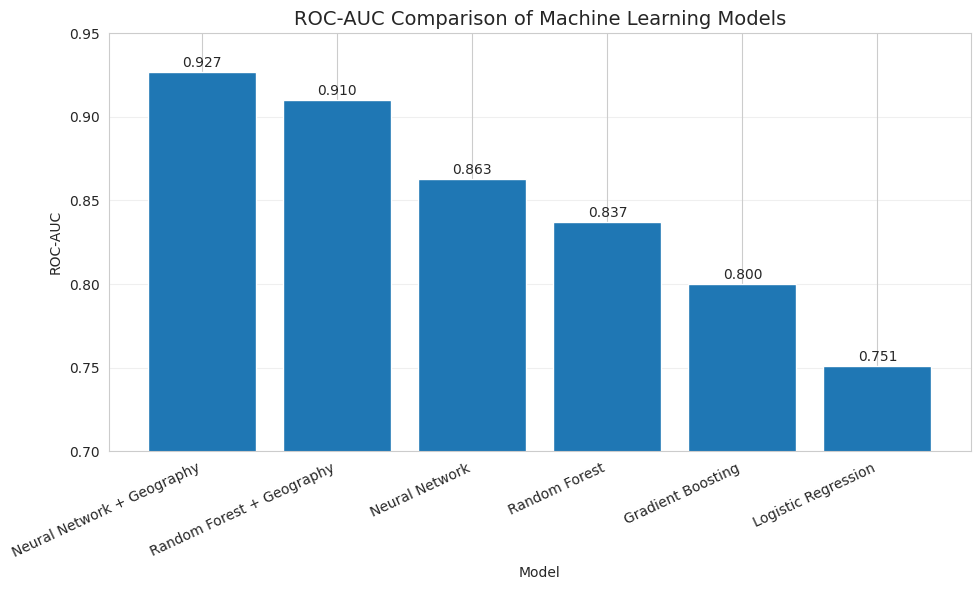

In [122]:
# Visualize ROC-AUC
# Sort models

model_comparison = model_comparison.sort_values(
    by='ROC-AUC',
    ascending=False
)

# Create Comparison Bar Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(
    model_comparison['Model'],
    model_comparison['ROC-AUC']
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f'{height:.3f}',
        ha='center',
        fontsize=10
    )

plt.title('ROC-AUC Comparison of Machine Learning Models', fontsize=14)
plt.xlabel('Model')
plt.ylabel('ROC-AUC')

plt.ylim(0.70, 0.95)

plt.xticks(rotation=25, ha='right')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

**Feature Importance Chart**

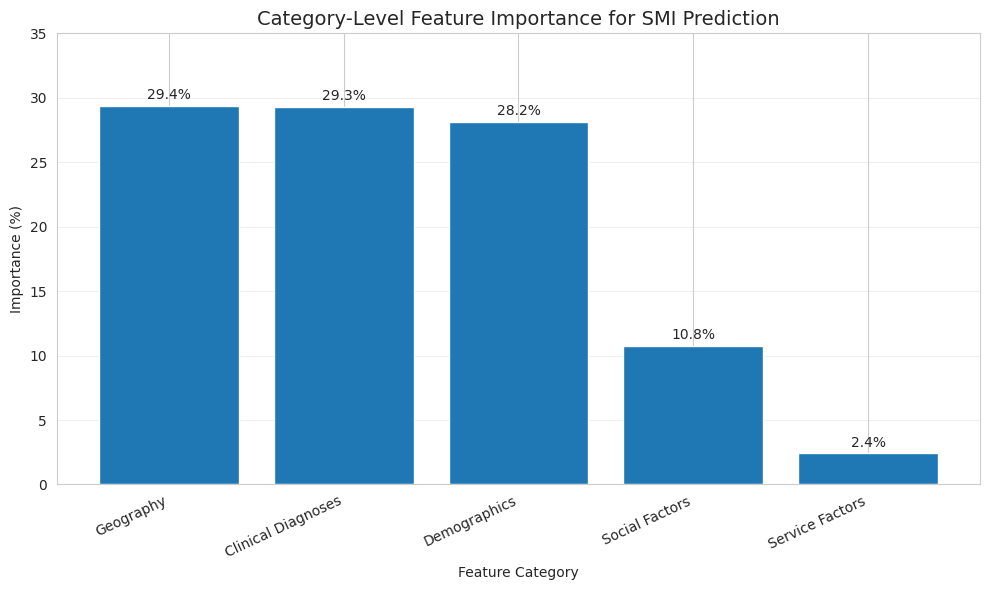

In [123]:
# ==========================================
# Category-Level Feature Importance Chart
# ==========================================

category_importance_pct = category_importance * 100

category_importance_pct = category_importance_pct.sort_values(ascending=False)

plt.figure(figsize=(10,6))

bars = plt.bar(
    category_importance_pct.index,
    category_importance_pct.values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        fontsize=10
    )

plt.title('Category-Level Feature Importance for SMI Prediction', fontsize=14)
plt.xlabel('Feature Category')
plt.ylabel('Importance (%)')

plt.ylim(0, 35)
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

**Combined Supervised and Unsupervised Model Comparison Table**

In [124]:
# ==========================================
# Combined Model Comparison Table
# ==========================================

model_comparison_full = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Gradient Boosting',
        'Random Forest',
        'Neural Network',
        'Random Forest + Geography',
        'Neural Network + Geography',
        'K-Means (K=2)',
        'K-Means (K=5)'
    ],

    'Learning Type': [
        'Supervised',
        'Supervised',
        'Supervised',
        'Supervised',
        'Supervised',
        'Supervised',
        'Unsupervised',
        'Unsupervised'
    ],

    'Primary Purpose': [
        'SMI prediction',
        'SMI prediction',
        'SMI prediction',
        'SMI prediction',
        'SMI prediction',
        'SMI prediction',
        'Client segmentation',
        'Exploratory client segmentation'
    ],

    'Primary Metric': [
        'ROC-AUC',
        'ROC-AUC',
        'ROC-AUC',
        'ROC-AUC',
        'ROC-AUC',
        'ROC-AUC',
        'Silhouette Score',
        'Silhouette Score'
    ],

    'Metric Value': [
        0.751,
        0.800,
        0.837,
        0.863,
        0.910,
        0.927,
        0.393,
        0.131
    ],

    'Key Finding': [
        'Baseline linear model',
        'Improved nonlinear performance',
        'Strong tree-based performance',
        'Best model before geography',
        'Geography improved performance',
        'Best overall predictive model',
        'Best primary segmentation solution',
        'Clinically meaningful exploratory subgroups'
    ]
})

model_comparison_full = model_comparison_full.round(3)

model_comparison_full

,Model,Learning Type,Primary Purpose,Primary Metric,Metric Value,Key Finding
0,Logistic Regression,Supervised,SMI prediction,ROC-AUC,0.751,Baseline linear model
1,Gradient Boosting,Supervised,SMI prediction,ROC-AUC,0.800,Improved nonlinear performance
2,Random Forest,Supervised,SMI prediction,ROC-AUC,0.837,Strong tree-based performance
3,Neural Network,Supervised,SMI prediction,ROC-AUC,0.863,Best model before geography
4,Random Forest + Geography,Supervised,SMI prediction,ROC-AUC,0.910,Geography improved performance
5,Neural Network + Geography,Supervised,SMI prediction,ROC-AUC,0.927,Best overall predictive model
6,K-Means (K=2),Unsupervised,Client segmentation,Silhouette Score,0.393,Best primary segmentation solution
7,K-Means (K=5),Unsupervised,Exploratory client segmentation,Silhouette Score,0.131,Clinically meaningful exploratory subgroups


**Executive Summary**

This project used both supervised and unsupervised machine learning to predict Serious Mental Illness (SMI) in adults using the Mental Health Client Level Data (MH-CLD 2023) of the Substance Abuse and Mental Health Services Administration (SAMHSA). We identified meaningful behavioral health client segments and important features that contributed to predictive value of SMI. Among the supervised models, the Neural Network with geographic variables model outperformed all other models by achieving an ROC-AUC of 0.927 and an accuracy of 0.844. This suggests that nonlinear machine learning models can efficiently identigy clients that are high risks for SMI classification, especially within a geographic context.

Additionally, the feature importance analysis showed that geography, clinical complexity and diagnosis, and demographics contributed nearly equal predictive value. This suggests that SMI classification of clients is influenced not only by their individual diagnosis, but by there demographic profile and the location where they receive their srvice.

The K-Means clustering analysis (unsupervised) identified two distinct primary client profiles. The first profile labeled the Severe Behavioral Health Complexity, is characterized by higher SMI prevalence, schizophrenia, substance use disorder, homelessness, unemployment, veteran representation, and more intensive service needs. The second cluster labeled the internalizing disorder cluster, is characterized by higher rates of anxiety, depression, trauma-related disorders, more private residence living, and lower SMI prevalence. A k-5 exploratory clustering model further revealed clinically meaningful subgroups, including anxiety complexity, substance use, personality disorder complexity, and psychotic-spectrum clusters.

Overall, this project demonstrates the effectiveness of machine learning within behavioral health and how it can support mental health risk prediction, client segmentation, enhance service planning, and be pivotal in future digital mental health product development.



**Business Recommendations**

Behavioral health organizations should use predictive analytics for early detection of clients at elevated risk of an SMI diagnosis in the care process to fast-track early intervention.

The Neural Network with Geography model is the most precise SMI classification support system with the overall best predictive performance. This suggests that geography is a strong indicator of high risk of an SMI diagonsis. Further exploration of the geographic pattern and influence, may reveal intervention, reporting, and policy gaps that should be addressed. Therefore, leaders should invest in and incorporate geographic level division interventions in management planning.

Finally, organizations should avoid creating a one-size-fits-all intervention pathway for clients. The clustering analysis revealed that clients fall into distinct categories with varying intervention needs and urgency. Treatment intervention pathways should be tailored to client clusters to give them the best experience and on-time needed service based on their presenting mental health problems.

Final implementation and deployment of this project in the real-world should include further fairness checks, external validation, review by licensed clinical mental health professionals, and business operations stakeholders.
